# Plotting CMB map from Multi-parametric model using camb library

In [2]:
import camb 
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt

<Figure size 1000x600 with 0 Axes>

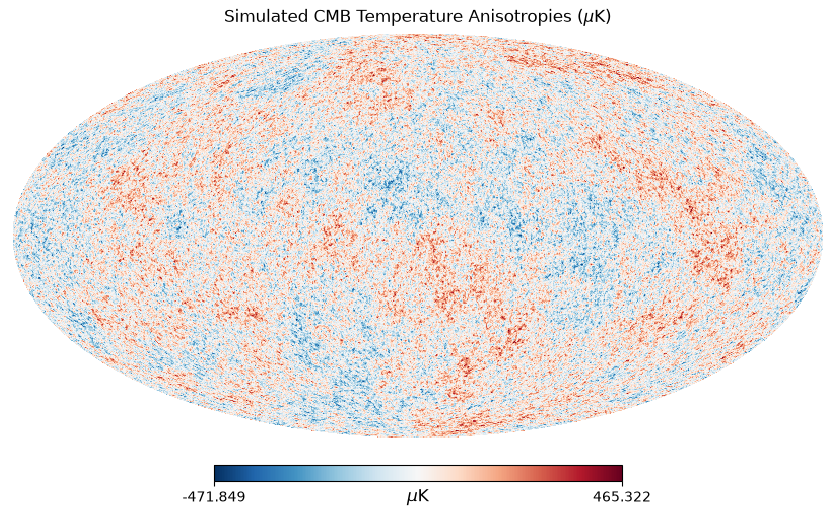

In [ ]:
# Step 1: Set cosmological parameters in CAMB
nside = 2048  # Map resolution 
lmax = 3 * nside - 1  # Standard max multipole rule for HEALPix

pars = camb.CAMBparams()
pars.set_cosmology(H0=67.4, ombh2=0.02237, omch2=0.1200, mnu=0.06, omk=0) # default Planck 2018 parameters
pars.InitPower.set_params(As=2.1e-9, ns=0.9649) 
pars.set_for_lmax(lmax, lens_potential_accuracy=0)

# Step 2: Compute C_l spectrum in uK^2
results = camb.get_results(pars)
powers = results.get_cmb_power_spectra(pars, CMB_unit="muK", raw_cl=True)

# 'unlensed_scalar' or 'total' gives [TT, EE, BB, TE]. Convert to 1D array of unscaled C_l (TT)
cl_tt = powers["total"][:, 0]

# Step 3: Generate a synthetic CMB map using hp.synfast
cmb_map = hp.synfast(cl_tt, nside=nside, lmax=lmax, new=True)

# Step 4: Display and Save the simulated map
plt.figure(figsize=(10, 6))
hp.mollview(
    cmb_map,
    title=r"Simulated CMB Temperature Anisotropies ($\mu\mathrm{K}$)",
    unit=r"$\mu\mathrm{K}$",
    cmap="RdBu_r",
)

plt.savefig("Saved Data/simulated_cmb_map.png", dpi=300, bbox_inches="tight")
plt.show()

---

In [ ]:
def plot_camb_spectrum_variation(param_name, param_values, obs_ell, obs_dl, base_params=None, lmax=2500, save_path=None):
    """Generates and plots CAMB spectra for varying values of a single cosmological parameter,

    overlaying the observed data.

    Parameters:
    -----------
    param_name : str
        Name of the parameter to vary ('H0', 'ombh2', 'omch2', 'ns', 'As', 'omk').
    param_values : list or np.ndarray
        Array of values to test for the specified parameter.
    obs_ell : np.ndarray
        Multipoles (ell) from observed map data.
    obs_dl : np.ndarray
        Angular power spectrum (Dl) from observed map data.
    base_params : dict, optional
        Baseline cosmological parameters.
    lmax : int, default=2500
        Maximum multipole to calculate.
    save_path : str, optional
        File path to save the generated plot.
    """
    # Default fiducial parameters (Planck 2018-like defaults)
    defaults = {"H0": 67.4,"ombh2": 0.02237,"omch2": 0.1200,"mnu": 0.06,"omk": 0,"As": 2.1e-9,"ns": 0.9649}

    if base_params is not None:
        defaults.update(base_params)

    plt.figure(figsize=(9, 5.5))

    for val in param_values:
        p = defaults.copy()
        p[param_name] = val

        # Configure CAMB parameters
        pars = camb.CAMBparams()
        pars.set_cosmology(H0=p["H0"],ombh2=p["ombh2"],omch2=p["omch2"],mnu=p["mnu"],omk=p["omk"])
        pars.InitPower.set_params(As=p["As"], ns=p["ns"])
        pars.set_for_lmax(lmax, lens_potential_accuracy=1)

        # Compute power spectrum
        results = camb.get_results(pars)
        powers = results.get_cmb_power_spectra(pars, CMB_unit="muK")
        totCL = powers["total"]
        ls = np.arange(totCL.shape[0])

        plt.plot(ls, totCL[:, 0], label=f"{param_name} = {val}")

    # Plot observed spectrum
    plt.plot(
        obs_ell[2:], obs_dl[2:], color="black", linewidth=1, alpha=0.75, label="Observed Data")

    plt.xlabel(r"Multipole $\ell$")
    plt.ylabel(r"$D_\ell^{\mathrm{TT}}$ ($\mu\mathrm{K}^2$)")
    plt.title(f"CAMB TT Spectrum Sensitivity to ${param_name}$")
    plt.xlim(2, lmax)
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.5)

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()

In [12]:
ell, cl, dl = np.loadtxt("Saved Data/APS_anafast.txt", skiprows=1, unpack=True)

## Comparing the Observed Angular power spectrum (Plancks) with the same of a universe of variations of different set of parameters 
### Different $H_0$ values 

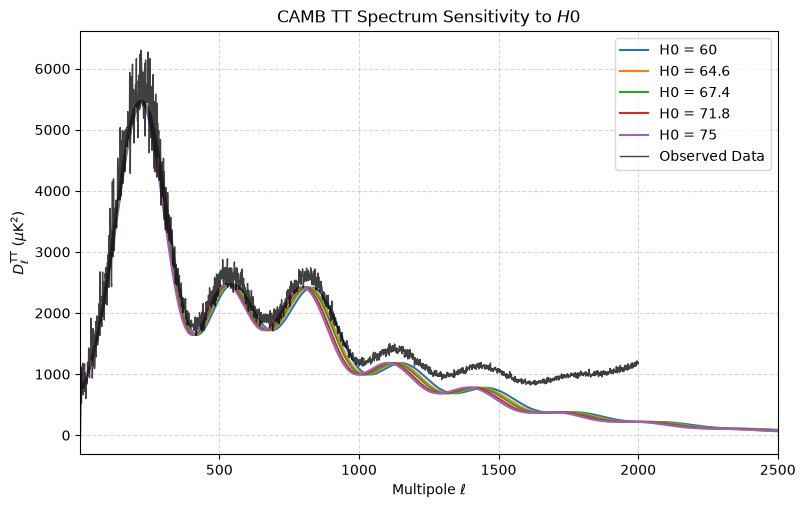

In [18]:
plot_camb_spectrum_variation(
    param_name="H0",
    param_values=[60, 64.6, 67.4, 71.8, 75],
    obs_ell=ell,
    obs_dl=dl,
    save_path="Saved Data/camb_spectrum_variation_H0.png")

Worth noting that as $H_0$ changes, the peaks moves horizontally leftwards

---
### Different $\Omega_b h^2$

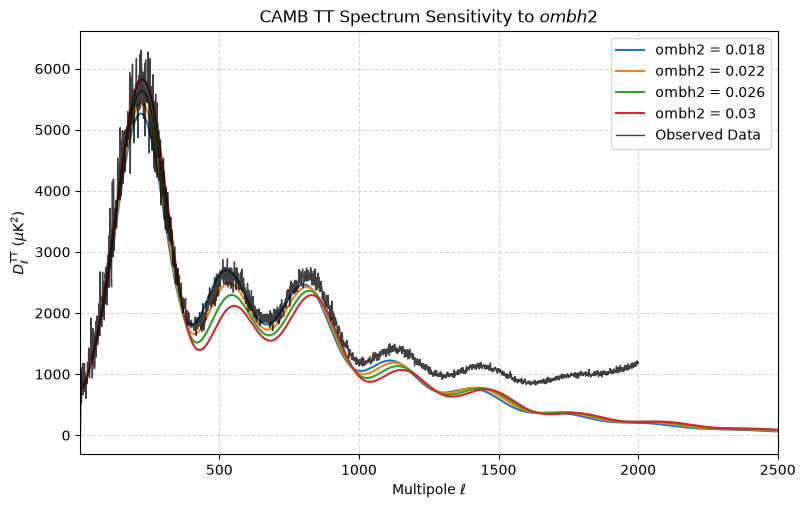

In [19]:
plot_camb_spectrum_variation(
    param_name="ombh2",
    param_values=[0.018, 0.022, 0.026, 0.030],
    obs_ell=ell,
    obs_dl=dl,
    save_path="Saved Data/camb_spectrum_variation_ombh2.png")

### Different $\Omega_c h^2$

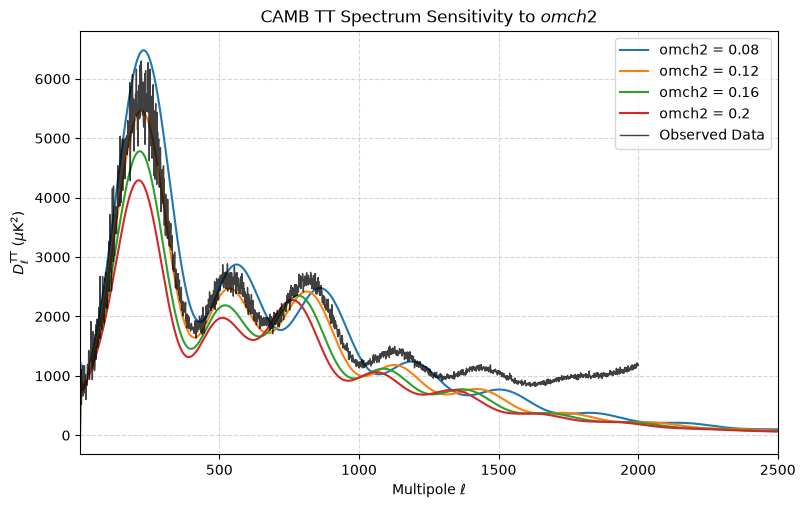

In [20]:
plot_camb_spectrum_variation(
    param_name="omch2",
    param_values=[0.08, 0.12, 0.16, 0.20],
    obs_ell=ell,
    obs_dl=dl,
    save_path="Saved Data/camb_spectrum_variation_omch2.png")

One can do this for different parameters and see how the plots(peaks) can move as you change a parameter